In [1]:
!pip install torch transformers rdkit fair-esm scipy scikit-learn pandas matplotlib seaborn tqdm PyTDC -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━

In [2]:
# ============================================================
# Cell 1a: Install Dependencies & Configuration
# ============================================================

# ======================== ALL CONFIGS ========================

# --- Paths ---
PROJECT_DIR = "/kaggle/working/"
CACHE_DIR = f"{PROJECT_DIR}/cache"
MODEL_SAVE_PATH = f"{PROJECT_DIR}/substruct_crossdti_best.pt"
RESULTS_PLOT_PATH = f"{PROJECT_DIR}/training_results.png"

# --- Pretrained Model Names ---
CHEMBERTA_MODEL = "seyonec/ChemBERTa-zinc250k-v1"  # Drug encoder (768-dim)
ESM2_MODEL = "esm2_t6_8M_UR50D"                     # Protein encoder (320-dim, 8M params)

# --- Dataset ---
DATASET_NAME = "DAVIS"           # TDC dataset name
TEST_SIZE = 0.2                  # Train/temp split ratio
VAL_TEST_RATIO = 0.5             # Val/test split from temp
RANDOM_SEED = 42

# --- Model Architecture ---
DRUG_DIM = 768                   # ChemBERTa output dim
PROTEIN_DIM = 320                # ESM-2 output dim
D_MODEL = 256                    # Shared hidden dimension
N_HEADS = 8                      # Number of attention heads
DROPOUT = 0.1
BIAS_SCALE = 5.0                 # Soft substructure attention bias
MLP_HIDDEN_DIM = 512             # Prediction head hidden dim

# --- Sequence Lengths ---
MAX_DRUG_LEN = 128               # Max SMILES token length
MAX_PROTEIN_LEN = 1024           # Max protein sequence length

# --- Training ---
BATCH_SIZE = 128
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0
LR_FACTOR = 0.5                 # ReduceLROnPlateau factor
LR_PATIENCE = 5                 # ReduceLROnPlateau patience
EARLY_STOP_PATIENCE = 15

# =============================================================
print("Configuration loaded.")
print(f"  Project dir: {PROJECT_DIR}")
print(f"  Drug encoder: {CHEMBERTA_MODEL}")
print(f"  Protein encoder: {ESM2_MODEL}")
print(f"  Dataset: {DATASET_NAME}")
print(f"  d_model={D_MODEL}, heads={N_HEADS}, batch={BATCH_SIZE}, lr={LEARNING_RATE}")

Configuration loaded.
  Project dir: /kaggle/working/
  Drug encoder: seyonec/ChemBERTa-zinc250k-v1
  Protein encoder: esm2_t6_8M_UR50D
  Dataset: DAVIS
  d_model=256, heads=8, batch=128, lr=0.0001


In [3]:
# ============================================================
# Cell 1b: Imports
# ============================================================

import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
from collections import defaultdict
from typing import List, Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from transformers import AutoModel, AutoTokenizer
import esm

from rdkit import Chem
from rdkit.Chem import AllChem, BRICS, Descriptors, rdMolDescriptors
from rdkit.Chem import rdmolops

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB


Downloading...
100%|██████████| 21.4M/21.4M [00:00<00:00, 45.8MiB/s]
Loading...
Done!


Dataset shape: (25772, 5)
Columns: ['Drug_ID', 'Drug', 'Target_ID', 'Target', 'Y']

Unique drugs: 68
Unique targets: 379

Affinity (Y) stats:
count    25772.000000
mean      7558.112997
std       3990.013578
min          0.016000
25%       3775.000000
50%      10000.000000
75%      10000.000000
max      10000.000000
Name: Y, dtype: float64

pKd stats:
count    25772.000000
mean         5.408461
std          0.831070
min          5.000000
25%          5.000000
50%          5.000000
75%          5.423112
max         10.795880
Name: pKd, dtype: float64

Split sizes — Train: 20617, Val: 2577, Test: 2578


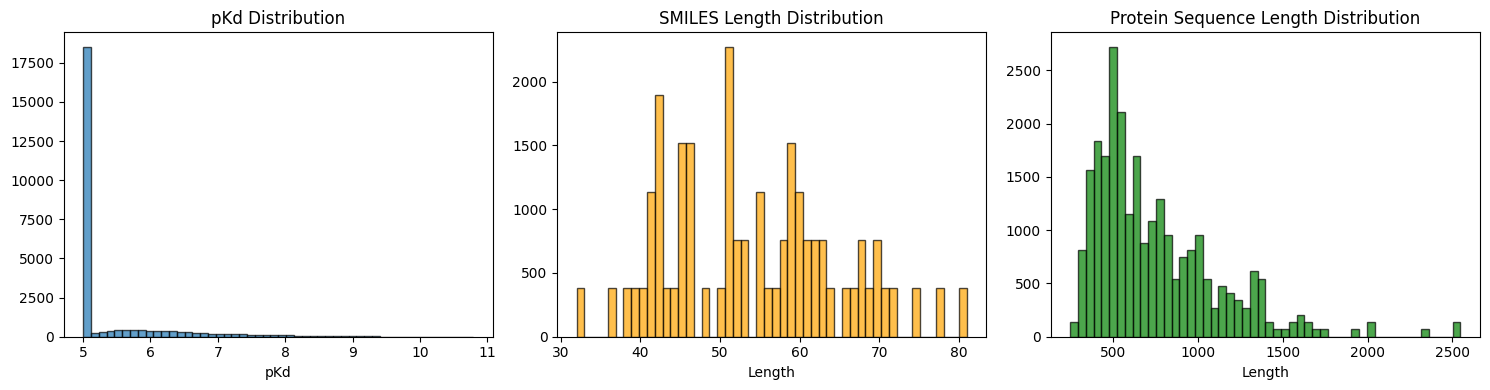


Max SMILES length: 81
Max protein length: 2549
Median SMILES length: 53.0
Median protein length: 632.0


In [4]:
# ============================================================
# Cell 2: Dataset Loading (Davis Kinase Binding Affinity)
# ============================================================

from tdc.multi_pred import DTI

data = DTI(name=DATASET_NAME)
df = data.get_data()

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nUnique drugs: {df['Drug'].nunique()}")
print(f"Unique targets: {df['Target'].nunique()}")
print(f"\nAffinity (Y) stats:")
print(df['Y'].describe())

# Convert Kd to pKd
df['pKd'] = -np.log10(df['Y'].clip(lower=1e-10) * 1e-9)

print(f"\npKd stats:")
print(df['pKd'].describe())

df = df.rename(columns={'Drug': 'smiles', 'Target': 'protein', 'Drug_ID': 'drug_id', 'Target_ID': 'target_id'})

# Train/Val/Test split
train_df, temp_df = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_SEED)
val_df, test_df = train_test_split(temp_df, test_size=VAL_TEST_RATIO, random_state=RANDOM_SEED)

print(f"\nSplit sizes — Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Visualize distributions
df['smiles_len'] = df['smiles'].str.len()
df['protein_len'] = df['protein'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['pKd'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('pKd Distribution')
axes[0].set_xlabel('pKd')

axes[1].hist(df['smiles_len'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('SMILES Length Distribution')
axes[1].set_xlabel('Length')

axes[2].hist(df['protein_len'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('Protein Sequence Length Distribution')
axes[2].set_xlabel('Length')

plt.tight_layout()
plt.show()

print(f"\nMax SMILES length: {df['smiles_len'].max()}")
print(f"Max protein length: {df['protein_len'].max()}")
print(f"Median SMILES length: {df['smiles_len'].median()}")
print(f"Median protein length: {df['protein_len'].median()}")

In [5]:
# ============================================================
# Cell 3: RDKit Substructure Extraction Utility
# ============================================================

# Define SMARTS patterns for common functional groups
FUNCTIONAL_GROUP_SMARTS = {
    'hydroxyl': '[OX2H]',
    'carboxyl': '[CX3](=O)[OX2H1]',
    'amine_primary': '[NX3;H2;!$(NC=O)]',
    'amine_secondary': '[NX3;H1;!$(NC=O)]',
    'amine_tertiary': '[NX3;H0;!$(NC=O)]',
    'amide': '[NX3][CX3](=[OX1])',
    'carbonyl': '[CX3]=[OX1]',
    'ether': '[OD2]([#6])[#6]',
    'ester': '[#6][CX3](=O)[OX2H0][#6]',
    'nitro': '[$([NX3](=O)=O),$([NX3+](=O)[O-])]',
    'sulfonyl': '[#16X4](=[OX1])(=[OX1])',
    'phosphate': '[PX4](=[OX1])([OX2])([OX2])[OX2]',
    'thiol': '[#16X2H]',
    'halide': '[F,Cl,Br,I]',
    'nitrile': '[NX1]#[CX2]',
    'alkene': '[CX3]=[CX3]',
    'alkyne': '[CX2]#[CX2]',
}


def get_atom_to_smiles_token_mapping(smiles: str, mol) -> Dict[int, List[int]]:
    """Map RDKit atom indices to SMILES character positions.
    
    This is needed because ChemBERTa tokenizes at character/subword level,
    while RDKit operates on atom indices. We need to bridge these two.
    """
    atom_to_chars = {}
    
    # Use RDKit's atom map to get character positions
    for atom in mol.GetAtoms():
        atom_idx = atom.GetIdx()
        # Get the atom's position in the SMILES string via atom mapping
        atom_to_chars[atom_idx] = []
    
    # Parse SMILES character by character to build atom-char mapping
    # We use RDKit's internal mapping
    atom_order = list(mol.GetPropsAsDict().get('_smilesAtomOutputOrder', range(mol.GetNumAtoms())))
    
    # Fallback: use canonical SMILES atom ordering
    try:
        # Generate canonical SMILES with atom map numbers
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(atom.GetIdx() + 1)
        mapped_smiles = Chem.MolToSmiles(mol)
        
        # Reset atom map numbers
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)
            
    except Exception:
        pass
    
    return atom_to_chars


def extract_substructures(smiles: str) -> Optional[Dict]:
    """Extract chemically meaningful substructures from a SMILES string.
    
    Returns:
        dict with:
            - 'mask': binary tensor (N_atoms x N_sub) mapping atoms to substructures
            - 'n_sub': number of substructures found
            - 'sub_names': human-readable names for each substructure
            - 'atom_indices': list of lists, atom indices per substructure
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    n_atoms = mol.GetNumAtoms()
    substructures = []  # list of (name, set_of_atom_indices)
    covered_atoms = set()
    
    # --- 1. Extract aromatic rings ---
    ring_info = mol.GetRingInfo()
    ring_idx = 0
    for ring in ring_info.AtomRings():
        # Check if ring is aromatic
        is_aromatic = all(mol.GetAtomWithIdx(a).GetIsAromatic() for a in ring)
        if is_aromatic:
            name = f"aromatic_ring_{ring_idx}"
            substructures.append((name, set(ring)))
            covered_atoms.update(ring)
            ring_idx += 1
    
    # --- 2. Extract non-aromatic rings ---
    non_arom_idx = 0
    for ring in ring_info.AtomRings():
        is_aromatic = all(mol.GetAtomWithIdx(a).GetIsAromatic() for a in ring)
        if not is_aromatic:
            name = f"ring_{non_arom_idx}"
            substructures.append((name, set(ring)))
            covered_atoms.update(ring)
            non_arom_idx += 1
    
    # --- 3. Extract functional groups via SMARTS ---
    for fg_name, smarts in FUNCTIONAL_GROUP_SMARTS.items():
        pattern = Chem.MolFromSmarts(smarts)
        if pattern is None:
            continue
        matches = mol.GetSubstructMatches(pattern)
        for i, match in enumerate(matches):
            match_set = set(match)
            # Only add if this group adds new atoms not fully covered
            if not match_set.issubset(covered_atoms):
                name = f"{fg_name}_{i}" if len(matches) > 1 else fg_name
                substructures.append((name, match_set))
                covered_atoms.update(match_set)
    
    # --- 4. BRICS-based fragments for remaining uncovered atoms ---
    try:
        brics_bonds = list(BRICS.FindBRICSBonds(mol))
        if brics_bonds:
            # Get fragments by breaking BRICS bonds
            bond_indices = []
            for (a1, a2), _ in brics_bonds:
                bond = mol.GetBondBetweenAtoms(a1, a2)
                if bond is not None:
                    bond_indices.append(bond.GetIdx())
            
            if bond_indices:
                frags = Chem.FragmentOnBonds(mol, bond_indices, addDummies=False)
                frag_atoms_list = Chem.GetMolFrags(frags, asMols=False)
                for i, frag_atoms in enumerate(frag_atoms_list):
                    frag_set = set(frag_atoms)
                    new_atoms = frag_set - covered_atoms
                    if new_atoms:
                        name = f"brics_frag_{i}"
                        substructures.append((name, frag_set))
                        covered_atoms.update(frag_set)
    except Exception:
        pass
    
    # --- 5. Singleton substructures for remaining uncovered atoms ---
    for a in range(n_atoms):
        if a not in covered_atoms:
            symbol = mol.GetAtomWithIdx(a).GetSymbol()
            substructures.append((f"atom_{symbol}_{a}", {a}))
            covered_atoms.add(a)
    
    # Build binary mask matrix: (N_atoms x N_sub)
    n_sub = len(substructures)
    if n_sub == 0:
        # Fallback: treat entire molecule as one substructure
        substructures = [("whole_mol", set(range(n_atoms)))]
        n_sub = 1
    
    mask = torch.zeros(n_atoms, n_sub, dtype=torch.float32)
    sub_names = []
    atom_indices_list = []
    
    for s_idx, (name, atom_set) in enumerate(substructures):
        sub_names.append(name)
        atom_indices_list.append(sorted(atom_set))
        for a_idx in atom_set:
            if a_idx < n_atoms:
                mask[a_idx, s_idx] = 1.0
    
    return {
        'mask': mask,              # (N_atoms, N_sub)
        'n_sub': n_sub,
        'n_atoms': n_atoms,
        'sub_names': sub_names,
        'atom_indices': atom_indices_list,
    }


# --- Test the extraction on a sample molecule ---
test_smiles = "CC(=O)Oc1ccccc1C(=O)O"  # Aspirin
result = extract_substructures(test_smiles)
if result:
    print(f"Molecule: Aspirin ({test_smiles})")
    print(f"Number of atoms: {result['n_atoms']}")
    print(f"Number of substructures: {result['n_sub']}")
    print(f"\nSubstructures found:")
    for name, atoms in zip(result['sub_names'], result['atom_indices']):
        print(f"  {name}: atoms {atoms}")
    print(f"\nMask shape: {result['mask'].shape}")
    print(f"Mask:\n{result['mask'].T}")  # Transpose for readability

Molecule: Aspirin (CC(=O)Oc1ccccc1C(=O)O)
Number of atoms: 13
Number of substructures: 6

Substructures found:
  aromatic_ring_0: atoms [4, 5, 6, 7, 8, 9]
  hydroxyl: atoms [12]
  carboxyl: atoms [10, 11, 12]
  carbonyl_0: atoms [1, 2]
  ether: atoms [1, 3, 4]
  ester: atoms [0, 1, 2, 3, 4]

Mask shape: torch.Size([13, 6])
Mask:
tensor([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
        [0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])


In [6]:
# ============================================================
# Cell 4: Drug Encoder (Frozen ChemBERTa)
# ============================================================

class DrugEncoder(nn.Module):
    """Encode drug SMILES using frozen ChemBERTa.
    Output: token-level embeddings H_d ∈ R^(L_d × 768)
    """
    
    def __init__(self, model_name=CHEMBERTA_MODEL, max_length=MAX_DRUG_LEN):
        super().__init__()
        self.max_length = max_length
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.encoder.config.hidden_size
        
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.encoder.eval()
    
    @torch.no_grad()
    def forward(self, smiles_list):
        encoded = self.tokenizer(
            smiles_list, padding=True, truncation=True,
            max_length=self.max_length, return_tensors='pt'
        )
        input_ids = encoded['input_ids'].to(next(self.encoder.parameters()).device)
        attention_mask = encoded['attention_mask'].to(next(self.encoder.parameters()).device)
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state, attention_mask


print("Loading ChemBERTa...")
drug_encoder = DrugEncoder().to(device)
print(f"ChemBERTa hidden size: {drug_encoder.hidden_size}")
print(f"Total params: {sum(p.numel() for p in drug_encoder.encoder.parameters()):,} (all frozen)")

test_smiles = ["CC(=O)Oc1ccccc1C(=O)O", "CC1=CC=CC=C1"]
with torch.no_grad():
    emb, mask = drug_encoder(test_smiles)
    print(f"\nTest output shape: {emb.shape}")
    print(f"Attention mask shape: {mask.shape}")

Loading ChemBERTa...


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc250k-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ChemBERTa hidden size: 768
Total params: 83,450,880 (all frozen)


model.safetensors:   0%|          | 0.00/336M [00:00<?, ?B/s]


Test output shape: torch.Size([2, 15, 768])
Attention mask shape: torch.Size([2, 15])


In [7]:
# ============================================================
# Cell 5: Target Encoder (Frozen ESM-2)
# ============================================================

class TargetEncoder(nn.Module):
    """Encode protein sequences using frozen ESM-2 (8M params).
    Output: residue-level embeddings H_p ∈ R^(L_p × 320)
    """
    
    def __init__(self, max_length=MAX_PROTEIN_LEN):
        super().__init__()
        self.max_length = max_length
        self.encoder, self.alphabet = esm.pretrained.esm2_t6_8M_UR50D()
        self.batch_converter = self.alphabet.get_batch_converter()
        self.hidden_size = 320
        
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.encoder.eval()
    
    @torch.no_grad()
    def forward(self, protein_sequences):
        truncated = [seq[:self.max_length] for seq in protein_sequences]
        data = [(f"protein_{i}", seq) for i, seq in enumerate(truncated)]
        batch_labels, batch_strs, batch_tokens = self.batch_converter(data)
        batch_tokens = batch_tokens.to(next(self.encoder.parameters()).device)
        
        results = self.encoder(batch_tokens, repr_layers=[6], return_contacts=False)
        embeddings = results["representations"][6][:, 1:-1, :]
        
        lengths = [len(seq) for seq in truncated]
        max_len = embeddings.shape[1]
        attention_mask = torch.zeros(len(protein_sequences), max_len, device=embeddings.device)
        for i, l in enumerate(lengths):
            attention_mask[i, :l] = 1.0
        
        return embeddings, attention_mask


print("Loading ESM-2 (8M)...")
target_encoder = TargetEncoder().to(device)
print(f"ESM-2 hidden size: {target_encoder.hidden_size}")
print(f"Total params: {sum(p.numel() for p in target_encoder.encoder.parameters()):,} (all frozen)")

test_proteins = ["MKTAYIAKQRQISFVKSHFSRQ", "AVILGPPGAGKSTFAR"]
with torch.no_grad():
    emb, mask = target_encoder(test_proteins)
    print(f"\nTest output shape: {emb.shape}")
    print(f"Attention mask shape: {mask.shape}")

Loading ESM-2 (8M)...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
ESM-2 hidden size: 320
Total params: 7,512,474 (all frozen)

Test output shape: torch.Size([2, 22, 320])
Attention mask shape: torch.Size([2, 22])


In [8]:
# ============================================================
# Cell 6: Substructure-aware Self-Attention & Aggregation
# ============================================================

class SubstructureSelfAttention(nn.Module):
    """Level 1: Refine drug token embeddings using substructure-aware self-attention.
    Uses a SOFT bias approach — same-substructure pairs get positive attention bias.
    """
    
    def __init__(self, input_dim=DRUG_DIM, n_heads=N_HEADS, dropout=DROPOUT, bias_scale=BIAS_SCALE):
        super().__init__()
        self.input_dim = input_dim
        self.n_heads = n_heads
        self.head_dim = input_dim // n_heads
        self.bias_scale = bias_scale
        
        self.q_proj = nn.Linear(input_dim, input_dim)
        self.k_proj = nn.Linear(input_dim, input_dim)
        self.v_proj = nn.Linear(input_dim, input_dim)
        self.out_proj = nn.Linear(input_dim, input_dim)
        
        self.layer_norm = nn.LayerNorm(input_dim)
        self.dropout = nn.Dropout(dropout)
        self._init_weights()
    
    def _init_weights(self):
        for module in [self.q_proj, self.k_proj, self.v_proj, self.out_proj]:
            nn.init.xavier_uniform_(module.weight, gain=0.1)
            nn.init.zeros_(module.bias)
    
    def forward(self, H_d, sub_mask, token_mask=None):
        batch_size, seq_len, _ = H_d.shape
        
        shared_sub = torch.bmm(sub_mask, sub_mask.transpose(1, 2))
        attn_bias = (shared_sub > 0).float() * self.bias_scale
        
        if token_mask is not None:
            pad_mask = token_mask.unsqueeze(1) * token_mask.unsqueeze(2)
            pad_mask_additive = torch.where(pad_mask > 0, 0.0, -1e9)
        else:
            pad_mask_additive = torch.zeros(batch_size, seq_len, seq_len, device=H_d.device)
        
        Q = self.q_proj(H_d).view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(H_d).view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(H_d).view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        scores = scores + attn_bias.unsqueeze(1) + pad_mask_additive.unsqueeze(1)
        
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)
        attn_weights = self.dropout(attn_weights)
        
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.input_dim)
        output = self.out_proj(context)
        
        H_d_refined = self.layer_norm(H_d + self.dropout(output))
        return H_d_refined


class SubstructureAggregator(nn.Module):
    """Aggregate token-level embeddings into substructure-level representations."""
    def __init__(self):
        super().__init__()
    
    def forward(self, H_d, sub_mask):
        mask_t = sub_mask.transpose(1, 2)
        H_sub = torch.bmm(mask_t, H_d)
        counts = mask_t.sum(dim=-1, keepdim=True).clamp(min=1.0)
        H_sub = H_sub / counts
        return H_sub


print("SubstructureSelfAttention params:", 
      sum(p.numel() for p in SubstructureSelfAttention().parameters() if p.requires_grad))
print("SubstructureAggregator params: 0 (no learnable params)")

SubstructureSelfAttention params: 2363904
SubstructureAggregator params: 0 (no learnable params)


In [9]:
# ============================================================
# Cell 7: Hierarchical Cross-Attention Block
# ============================================================

class HierarchicalCrossAttention(nn.Module):
    """Level 2: Cross-attention between drug substructures (Q) and protein residues (K, V).
    Produces an interpretable attention map A ∈ R^(N_sub × L_p).
    """
    
    def __init__(self, drug_dim=DRUG_DIM, protein_dim=PROTEIN_DIM, d_model=D_MODEL, 
                 n_heads=N_HEADS, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        self.drug_proj = nn.Linear(drug_dim, d_model)
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(protein_dim, d_model)
        self.v_proj = nn.Linear(protein_dim, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.ffn_norm = nn.LayerNorm(d_model)
        self._init_weights()
    
    def _init_weights(self):
        for module in [self.drug_proj, self.q_proj, self.k_proj, self.v_proj, self.out_proj]:
            nn.init.xavier_uniform_(module.weight, gain=0.1)
            nn.init.zeros_(module.bias)
        for module in self.ffn:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.1)
                nn.init.zeros_(module.bias)
    
    def forward(self, H_sub, H_p, sub_padding_mask=None, protein_padding_mask=None):
        batch_size, n_sub, _ = H_sub.shape
        l_p = H_p.shape[1]
        
        H_sub_proj = self.drug_proj(H_sub)
        
        Q = self.q_proj(H_sub_proj).view(batch_size, n_sub, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(H_p).view(batch_size, l_p, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(H_p).view(batch_size, l_p, self.n_heads, self.head_dim).transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        
        if protein_padding_mask is not None:
            scores = scores.masked_fill(protein_padding_mask.unsqueeze(1).unsqueeze(2) == 0, -1e9)
        if sub_padding_mask is not None:
            scores = scores.masked_fill(sub_padding_mask.unsqueeze(1).unsqueeze(3) == 0, -1e9)
        
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)
        
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, n_sub, self.d_model)
        context = self.out_proj(context)
        
        context = self.layer_norm(H_sub_proj + self.dropout(context))
        context = self.ffn_norm(context + self.ffn(context))
        
        attn_map = attn_weights.mean(dim=1)
        return context, attn_map


cross_attn = HierarchicalCrossAttention()
print(f"HierarchicalCrossAttention trainable params: {sum(p.numel() for p in cross_attn.parameters() if p.requires_grad):,}")

HierarchicalCrossAttention trainable params: 1,019,392


In [10]:
# ============================================================
# Cell 8: Prediction Head
# ============================================================

class PredictionHead(nn.Module):
    """MLP prediction head for binding affinity regression."""
    
    def __init__(self, d_model=D_MODEL, protein_dim=PROTEIN_DIM, hidden_dim=MLP_HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.protein_proj = nn.Linear(protein_dim, d_model)
        self.mlp = nn.Sequential(
            nn.Linear(2 * d_model, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, drug_context, H_p, sub_padding_mask=None, protein_padding_mask=None):
        if sub_padding_mask is not None:
            mask = sub_padding_mask.unsqueeze(-1)
            drug_pooled = (drug_context * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        else:
            drug_pooled = drug_context.mean(dim=1)
        
        H_p_proj = self.protein_proj(H_p)
        if protein_padding_mask is not None:
            mask = protein_padding_mask.unsqueeze(-1)
            protein_pooled = (H_p_proj * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        else:
            protein_pooled = H_p_proj.mean(dim=1)
        
        combined = torch.cat([drug_pooled, protein_pooled], dim=-1)
        return self.mlp(combined)


pred_head = PredictionHead()
print(f"PredictionHead trainable params: {sum(p.numel() for p in pred_head.parameters() if p.requires_grad):,}")

PredictionHead trainable params: 476,417


In [11]:
# ============================================================
# Cell 9: Full Model Assembly — SubStructCrossDTI
# ============================================================

class SubStructCrossDTI(nn.Module):
    """SubStruct-CrossDTI: Lightweight Hierarchical Cross-Attention for DTI Prediction.
    
    Architecture:
        1. Drug Encoder (frozen ChemBERTa) → token embeddings (L_d × 768)
        2. Target Encoder (frozen ESM-2) → residue embeddings (L_p × 320)
        3. Substructure-aware Self-Attention on drug branch
        4. Substructure Aggregation → (N_sub × 768)
        5. Hierarchical Cross-Attention (drug subs × protein residues) → interaction map
        6. Prediction Head → pKd scalar
    """
    
    def __init__(self, drug_dim=768, protein_dim=320, d_model=256, 
                 n_heads=8, dropout=0.1, max_drug_len=128, max_protein_len=1024):
        super().__init__()
        
        # Frozen encoders
        self.drug_encoder = DrugEncoder(max_length=max_drug_len)
        self.target_encoder = TargetEncoder(max_length=max_protein_len)
        
        # Trainable modules
        self.self_attention = SubstructureSelfAttention(
            input_dim=drug_dim, n_heads=n_heads, dropout=dropout
        )
        self.aggregator = SubstructureAggregator()
        self.cross_attention = HierarchicalCrossAttention(
            drug_dim=drug_dim, protein_dim=protein_dim, 
            d_model=d_model, n_heads=n_heads, dropout=dropout
        )
        self.prediction_head = PredictionHead(
            d_model=d_model, protein_dim=protein_dim, 
            hidden_dim=512, dropout=dropout
        )
        
        self.drug_dim = drug_dim
        self.protein_dim = protein_dim
        self.d_model = d_model
    
    def forward(self, smiles_list: List[str], protein_list: List[str],
                sub_masks: List[torch.Tensor], sub_n_subs: List[int]) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            smiles_list: list of SMILES strings (batch)
            protein_list: list of protein sequences (batch)
            sub_masks: list of substructure masks, each (N_atoms_i, N_sub_i)
            sub_n_subs: list of N_sub counts per sample
        Returns:
            pKd: (batch, 1) predicted binding affinity
            attn_map: (batch, max_N_sub, max_L_p) attention map
        """
        batch_size = len(smiles_list)
        
        # --- Step 1: Encode drugs (frozen) ---
        H_d, drug_mask = self.drug_encoder(smiles_list)  # (batch, L_d, 768), (batch, L_d)
        
        # --- Step 2: Encode proteins (frozen) ---
        H_p, protein_mask = self.target_encoder(protein_list)  # (batch, L_p, 320), (batch, L_p)
        
        # --- Step 3: Pad substructure masks to batch ---
        L_d = H_d.shape[1]
        max_n_sub = max(sub_n_subs)
        
        # Create padded substructure mask: (batch, L_d, max_N_sub)
        padded_sub_mask = torch.zeros(batch_size, L_d, max_n_sub, device=H_d.device)
        sub_padding_mask = torch.zeros(batch_size, max_n_sub, device=H_d.device)
        
        for i, (mask, n_sub) in enumerate(zip(sub_masks, sub_n_subs)):
            n_atoms = min(mask.shape[0], L_d)
            n_s = min(mask.shape[1], max_n_sub)
            padded_sub_mask[i, :n_atoms, :n_s] = mask[:n_atoms, :n_s].to(H_d.device)
            sub_padding_mask[i, :n_sub] = 1.0
        
        # --- Step 4: Substructure-aware Self-Attention ---
        H_d_refined = self.self_attention(H_d, padded_sub_mask, drug_mask)
        
        # --- Step 5: Aggregate to substructure level ---
        H_sub = self.aggregator(H_d_refined, padded_sub_mask)  # (batch, max_N_sub, 768)
        
        # --- Step 6: Hierarchical Cross-Attention ---
        context, attn_map = self.cross_attention(
            H_sub, H_p, 
            sub_padding_mask=sub_padding_mask,
            protein_padding_mask=protein_mask
        )
        
        # --- Step 7: Predict pKd ---
        pKd = self.prediction_head(
            context, H_p,
            sub_padding_mask=sub_padding_mask,
            protein_padding_mask=protein_mask
        )
        
        return pKd, attn_map
    
    def count_trainable_params(self):
        """Count only trainable parameters (excludes frozen encoders)."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
    def count_total_params(self):
        """Count all parameters including frozen encoders."""
        return sum(p.numel() for p in self.parameters())


# Build model
print("Building SubStruct-CrossDTI model...")
model = SubStructCrossDTI().to(device)

print(f"\nTrainable parameters: {model.count_trainable_params():,}")
print(f"Total parameters (incl. frozen): {model.count_total_params():,}")
print(f"Frozen encoder params: {model.count_total_params() - model.count_trainable_params():,}")

# List trainable modules
print("\nTrainable modules:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.shape}")

Building SubStruct-CrossDTI model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc250k-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Trainable parameters: 3,859,713
Total parameters (incl. frozen): 94,823,067
Frozen encoder params: 90,963,354

Trainable modules:
  self_attention.q_proj.weight: torch.Size([768, 768])
  self_attention.q_proj.bias: torch.Size([768])
  self_attention.k_proj.weight: torch.Size([768, 768])
  self_attention.k_proj.bias: torch.Size([768])
  self_attention.v_proj.weight: torch.Size([768, 768])
  self_attention.v_proj.bias: torch.Size([768])
  self_attention.out_proj.weight: torch.Size([768, 768])
  self_attention.out_proj.bias: torch.Size([768])
  self_attention.layer_norm.weight: torch.Size([768])
  self_attention.layer_norm.bias: torch.Size([768])
  cross_attention.drug_proj.weight: torch.Size([256, 768])
  cross_attention.drug_proj.bias: torch.Size([256])
  cross_attention.q_proj.weight: torch.Size([256, 256])
  cross_attention.q_proj.bias: torch.Size([256])
  cross_attention.k_proj.weight: torch.Size([256, 320])
  cross_attention.k_proj.bias: torch.Size([256])
  cross_attention.v_proj.w

In [12]:
# ============================================================
# Cell 10: Dataset & DataLoader with Embedding Caching
# ============================================================

class DTIDataset(Dataset):
    """Dataset for Drug-Target Interaction prediction.
    Pre-computes and caches RDKit masks, ChemBERTa and ESM-2 embeddings.
    """
    
    def __init__(self, df, drug_encoder, target_encoder, cache_dir=CACHE_DIR,
                 max_protein_len=MAX_PROTEIN_LEN):
        self.df = df.reset_index(drop=True)
        self.cache_dir = cache_dir
        os.makedirs(cache_dir, exist_ok=True)
        
        unique_smiles = df['smiles'].unique().tolist()
        unique_proteins = df['protein'].unique().tolist()
        print(f"Unique drugs: {len(unique_smiles)}, Unique proteins: {len(unique_proteins)}")
        
        # Cache substructure masks
        self.sub_cache = {}
        failed = 0
        for smi in tqdm(unique_smiles, desc="RDKit substructures"):
            result = extract_substructures(smi)
            if result is not None:
                self.sub_cache[smi] = result
            else:
                failed += 1
                self.sub_cache[smi] = {
                    'mask': torch.ones(1, 1), 'n_sub': 1, 'n_atoms': 1,
                    'sub_names': ['unknown'], 'atom_indices': [[0]],
                }
        if failed > 0:
            print(f"Warning: {failed} SMILES failed RDKit parsing")
        
        # Cache drug embeddings
        drug_cache_path = os.path.join(cache_dir, "drug_embeddings.pkl")
        if os.path.exists(drug_cache_path):
            print("Loading cached drug embeddings...")
            with open(drug_cache_path, 'rb') as f:
                self.drug_emb_cache = pickle.load(f)
        else:
            print("Computing drug embeddings (ChemBERTa)...")
            self.drug_emb_cache = {}
            drug_encoder.eval()
            for i in tqdm(range(0, len(unique_smiles), 32), desc="Drug embeddings"):
                batch = unique_smiles[i:i+32]
                with torch.no_grad():
                    emb, mask = drug_encoder(batch)
                    emb, mask = emb.cpu(), mask.cpu()
                for j, smi in enumerate(batch):
                    self.drug_emb_cache[smi] = {'embedding': emb[j], 'mask': mask[j]}
            with open(drug_cache_path, 'wb') as f:
                pickle.dump(self.drug_emb_cache, f)
            print(f"Saved drug embeddings to {drug_cache_path}")
        
        # Cache protein embeddings
        protein_cache_path = os.path.join(cache_dir, "protein_embeddings.pkl")
        if os.path.exists(protein_cache_path):
            print("Loading cached protein embeddings...")
            with open(protein_cache_path, 'rb') as f:
                self.protein_emb_cache = pickle.load(f)
        else:
            print("Computing protein embeddings (ESM-2)...")
            self.protein_emb_cache = {}
            target_encoder.eval()
            for prot in tqdm(unique_proteins, desc="Protein embeddings"):
                with torch.no_grad():
                    emb, mask = target_encoder([prot])
                    emb, mask = emb.cpu(), mask.cpu()
                self.protein_emb_cache[prot] = {'embedding': emb[0], 'mask': mask[0]}
            with open(protein_cache_path, 'wb') as f:
                pickle.dump(self.protein_emb_cache, f)
            print(f"Saved protein embeddings to {protein_cache_path}")
        
        print(f"Dataset ready: {len(self.df)} samples")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        smiles, protein, pKd = row['smiles'], row['protein'], row['pKd']
        drug_data = self.drug_emb_cache[smiles]
        protein_data = self.protein_emb_cache[protein]
        sub_data = self.sub_cache[smiles]
        return {
            'drug_emb': drug_data['embedding'], 'drug_mask': drug_data['mask'],
            'protein_emb': protein_data['embedding'], 'protein_mask': protein_data['mask'],
            'sub_mask': sub_data['mask'], 'n_sub': sub_data['n_sub'],
            'sub_names': sub_data['sub_names'],
            'pKd': torch.tensor(pKd, dtype=torch.float32),
            'smiles': smiles, 'protein': protein,
        }


def collate_fn(batch):
    """Custom collate function to handle variable-length sequences."""
    max_drug_len = max(item['drug_emb'].shape[0] for item in batch)
    max_protein_len = max(item['protein_emb'].shape[0] for item in batch)
    max_n_sub = max(item['n_sub'] for item in batch)
    
    batch_size = len(batch)
    drug_dim = batch[0]['drug_emb'].shape[1]
    protein_dim = batch[0]['protein_emb'].shape[1]
    
    drug_embs = torch.zeros(batch_size, max_drug_len, drug_dim)
    drug_masks = torch.zeros(batch_size, max_drug_len)
    protein_embs = torch.zeros(batch_size, max_protein_len, protein_dim)
    protein_masks = torch.zeros(batch_size, max_protein_len)
    sub_masks = torch.zeros(batch_size, max_drug_len, max_n_sub)
    sub_padding_masks = torch.zeros(batch_size, max_n_sub)
    pKds = torch.zeros(batch_size)
    n_subs, smiles_list, protein_list, sub_names_list = [], [], [], []
    
    for i, item in enumerate(batch):
        ld, lp = item['drug_emb'].shape[0], item['protein_emb'].shape[0]
        na, ns = item['sub_mask'].shape[0], item['n_sub']
        
        drug_embs[i, :ld] = item['drug_emb']
        drug_masks[i, :ld] = item['drug_mask']
        protein_embs[i, :lp] = item['protein_emb']
        protein_masks[i, :lp] = item['protein_mask']
        
        n_a, n_s = min(na, max_drug_len), min(ns, max_n_sub)
        sub_masks[i, :n_a, :n_s] = item['sub_mask'][:n_a, :n_s]
        sub_padding_masks[i, :ns] = 1.0
        
        pKds[i] = item['pKd']
        n_subs.append(ns)
        smiles_list.append(item['smiles'])
        protein_list.append(item['protein'])
        sub_names_list.append(item['sub_names'])
    
    return {
        'drug_emb': drug_embs, 'drug_mask': drug_masks,
        'protein_emb': protein_embs, 'protein_mask': protein_masks,
        'sub_mask': sub_masks, 'sub_padding_mask': sub_padding_masks,
        'n_sub': n_subs, 'pKd': pKds,
        'smiles': smiles_list, 'protein': protein_list, 'sub_names': sub_names_list,
    }


# Build datasets
print("Building datasets...")
train_dataset = DTIDataset(train_df, drug_encoder, target_encoder)
val_dataset = DTIDataset(val_df, drug_encoder, target_encoder)
test_dataset = DTIDataset(test_df, drug_encoder, target_encoder)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         collate_fn=collate_fn, num_workers=0)

print(f"\nTrain batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  drug_emb: {batch['drug_emb'].shape}")
print(f"  protein_emb: {batch['protein_emb'].shape}")
print(f"  sub_mask: {batch['sub_mask'].shape}")
print(f"  pKd: {batch['pKd'].shape}")

Building datasets...
Unique drugs: 68, Unique proteins: 379


RDKit substructures:   0%|          | 0/68 [00:00<?, ?it/s]

Computing drug embeddings (ChemBERTa)...


Drug embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Saved drug embeddings to /kaggle/working//cache/drug_embeddings.pkl
Computing protein embeddings (ESM-2)...


...

Saved protein embeddings to /kaggle/working//cache/protein_embeddings.pkl
Dataset ready: 20617 samples
Unique drugs: 68, Unique proteins: 379


RDKit substructures:   0%|          | 0/68 [00:00<?, ?it/s]

Loading cached drug embeddings...
Loading cached protein embeddings...
Dataset ready: 2577 samples
Unique drugs: 68, Unique proteins: 379


RDKit substructures:   0%|          | 0/68 [00:00<?, ?it/s]

Loading cached drug embeddings...
Loading cached protein embeddings...
Dataset ready: 2578 samples

Train batches: 161, Val batches: 21, Test batches: 21

Sample batch shapes:
  drug_emb: torch.Size([128, 59, 768])
  protein_emb: torch.Size([128, 1024, 320])
  sub_mask: torch.Size([128, 59, 16])
  pKd: torch.Size([128])


In [13]:
# ============================================================
# Cell 11: Training Loop (using cached embeddings)
# ============================================================

class SubStructCrossDTI_Cached(nn.Module):
    """Model using pre-cached embeddings (skips frozen encoder forward passes)."""
    
    def __init__(self, drug_dim=DRUG_DIM, protein_dim=PROTEIN_DIM, d_model=D_MODEL, 
                 n_heads=N_HEADS, dropout=DROPOUT):
        super().__init__()
        self.self_attention = SubstructureSelfAttention(input_dim=drug_dim, n_heads=n_heads, dropout=dropout)
        self.aggregator = SubstructureAggregator()
        self.cross_attention = HierarchicalCrossAttention(
            drug_dim=drug_dim, protein_dim=protein_dim, d_model=d_model, n_heads=n_heads, dropout=dropout)
        self.prediction_head = PredictionHead(
            d_model=d_model, protein_dim=protein_dim, hidden_dim=MLP_HIDDEN_DIM, dropout=dropout)
        self.d_model = d_model
    
    def forward(self, drug_emb, drug_mask, protein_emb, protein_mask, sub_mask, sub_padding_mask):
        H_d_refined = self.self_attention(drug_emb, sub_mask, drug_mask)
        H_sub = self.aggregator(H_d_refined, sub_mask)
        context, attn_map = self.cross_attention(
            H_sub, protein_emb, sub_padding_mask=sub_padding_mask, protein_padding_mask=protein_mask)
        pKd = self.prediction_head(
            context, protein_emb, sub_padding_mask=sub_padding_mask, protein_padding_mask=protein_mask)
        return pKd, attn_map


def ci_fast(y_true, y_pred):
    """Fast CI computation."""
    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()
    valid_mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[valid_mask], y_pred[valid_mask]
    n = len(y_true)
    if n < 2: return 0.5
    if n > 5000:
        idx = np.random.choice(n, 5000, replace=False)
        y_true, y_pred, n = y_true[idx], y_pred[idx], 5000
    diff_true = y_true[:, None] - y_true[None, :]
    diff_pred = y_pred[:, None] - y_pred[None, :]
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    diff_true, diff_pred = diff_true[mask], diff_pred[mask]
    valid = diff_true != 0
    if valid.sum() == 0: return 0.5
    concordant = ((diff_true[valid] * diff_pred[valid]) > 0).sum()
    tied = (diff_pred[valid] == 0).sum()
    return (concordant + 0.5 * tied) / valid.sum()


def safe_metrics(all_targets, all_preds):
    """Compute metrics with NaN safety."""
    t, p = np.array(all_targets).flatten(), np.array(all_preds).flatten()
    valid = np.isfinite(t) & np.isfinite(p)
    if valid.sum() < 2:
        return {'mse': float('inf'), 'rmse': float('inf'), 'r2': 0.0, 'pearson_r': 0.0, 'ci': 0.5}
    t, p = t[valid], p[valid]
    mse = float(np.mean((t - p) ** 2))
    ss_res, ss_tot = np.sum((t - p) ** 2), np.sum((t - np.mean(t)) ** 2)
    r2 = float(1 - ss_res / max(ss_tot, 1e-10))
    pearson_r = float(np.corrcoef(t, p)[0, 1]) if np.std(t) > 0 and np.std(p) > 0 else 0.0
    return {'mse': mse, 'rmse': float(np.sqrt(mse)), 'r2': r2, 'pearson_r': pearson_r, 'ci': float(ci_fast(t, p))}


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n_batches = 0, 0
    for batch in tqdm(loader, desc="Training", leave=False):
        d_emb = batch['drug_emb'].to(device)
        d_mask = batch['drug_mask'].to(device)
        p_emb = batch['protein_emb'].to(device)
        p_mask = batch['protein_mask'].to(device)
        s_mask = batch['sub_mask'].to(device)
        sp_mask = batch['sub_padding_mask'].to(device)
        targets = batch['pKd'].to(device)
        
        optimizer.zero_grad()
        pred, _ = model(d_emb, d_mask, p_emb, p_mask, s_mask, sp_mask)
        pred = pred.squeeze(-1)
        
        if torch.isnan(pred).any():
            print("  [WARNING] NaN in predictions, skipping batch")
            continue
        
        loss = criterion(pred, targets)
        if torch.isnan(loss):
            print("  [WARNING] NaN loss, skipping batch")
            continue
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n_batches = 0, 0
    all_preds, all_targets = [], []
    for batch in tqdm(loader, desc="Evaluating", leave=False):
        d_emb = batch['drug_emb'].to(device)
        d_mask = batch['drug_mask'].to(device)
        p_emb = batch['protein_emb'].to(device)
        p_mask = batch['protein_mask'].to(device)
        s_mask = batch['sub_mask'].to(device)
        sp_mask = batch['sub_padding_mask'].to(device)
        targets = batch['pKd'].to(device)
        
        pred, _ = model(d_emb, d_mask, p_emb, p_mask, s_mask, sp_mask)
        pred = pred.squeeze(-1)
        if torch.isnan(pred).any():
            pred = torch.nan_to_num(pred, nan=targets.mean().item())
        
        loss = criterion(pred, targets)
        if not torch.isnan(loss):
            total_loss += loss.item()
        n_batches += 1
        all_preds.extend(pred.cpu().numpy().tolist())
        all_targets.extend(targets.cpu().numpy().tolist())
    
    metrics = safe_metrics(all_targets, all_preds)
    metrics['loss'] = total_loss / max(n_batches, 1)
    return metrics, np.array(all_preds), np.array(all_targets)


# ==========================================
# Build model and debug
# ==========================================
model_cached = SubStructCrossDTI_Cached().to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model_cached.parameters() if p.requires_grad):,}")

# Debug forward pass
model_cached.eval()
debug_batch = next(iter(train_loader))
with torch.no_grad():
    pred, attn = model_cached(
        debug_batch['drug_emb'].to(device), debug_batch['drug_mask'].to(device),
        debug_batch['protein_emb'].to(device), debug_batch['protein_mask'].to(device),
        debug_batch['sub_mask'].to(device), debug_batch['sub_padding_mask'].to(device))
    print(f"Debug — pred: {pred[:5].squeeze().tolist()}, NaN: {torch.isnan(pred).any().item()}")

# ==========================================
# Training
# ==========================================
criterion = nn.MSELoss()
optimizer = Adam(model_cached.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)

history = {'train_loss': [], 'val_loss': [], 'val_mse': [], 'val_rmse': [], 'val_ci': [], 'val_pearson': []}
best_val_loss, best_model_state, patience_counter = float('inf'), None, 0

print(f"\nStarting training for {NUM_EPOCHS} epochs...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val MSE':>10} | {'Val CI':>10} | {'Val R':>10} | {'LR':>10}")
print("-" * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model_cached, train_loader, optimizer, criterion, device)
    val_metrics, _, _ = evaluate(model_cached, val_loader, criterion, device)
    
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_metrics['loss'])
    new_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_mse'].append(val_metrics['mse'])
    history['val_rmse'].append(val_metrics['rmse'])
    history['val_ci'].append(val_metrics['ci'])
    history['val_pearson'].append(val_metrics['pearson_r'])
    
    lr_note = " *LR reduced" if new_lr < old_lr else ""
    print(f"{epoch:5d} | {train_loss:10.4f} | {val_metrics['loss']:10.4f} | "
          f"{val_metrics['mse']:10.4f} | {val_metrics['ci']:10.4f} | "
          f"{val_metrics['pearson_r']:10.4f} | {new_lr:10.6f}{lr_note}")
    
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        best_model_state = {k: v.clone() for k, v in model_cached.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (patience={EARLY_STOP_PATIENCE})")
            break

if best_model_state is not None:
    model_cached.load_state_dict(best_model_state)
    print(f"\nRestored best model (val_loss={best_val_loss:.4f})")

torch.save(best_model_state, MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

Trainable parameters: 3,859,713
Debug — pred: [-0.017978353425860405, -0.03508100286126137, -0.03399312123656273, -0.02151491492986679, 0.0020668208599090576], NaN: False

Starting training for 100 epochs...
Epoch | Train Loss |   Val Loss |    Val MSE |     Val CI |      Val R |         LR
--------------------------------------------------------------------------------


Training:   0%|          | 0/161 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

    1 |     2.5959 |     0.4494 |     0.4430 |     0.7660 |     0.5418 |   0.000100


Training:   0%|          | 0/161 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

   41 |     0.2867 |     0.2811 |     0.2848 |     0.8595 |     0.7799 |   0.000025


Training:   0%|          | 0/161 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

   42 |     0.2840 |     0.2616 |     0.2642 |     0.8618 |     0.7785 |   0.000025

Early stopping at epoch 42 (patience=15)

Restored best model (val_loss=0.2545)
Model saved to /kaggle/working//substruct_crossdti_best.pt


In [14]:
# ============================================================
# Cell 12a: Baseline Models (DeepDTA + MolTrans) — Same Split
# ============================================================
# Pre-encode strings to tensors ONCE, then train entirely on GPU.

# ==========================================
# Shared: Pre-encode all SMILES and proteins to integer tensors
# ==========================================

SMILES_CHAR_MAP = {c: i+1 for i, c in enumerate(
    "CcOoNnSsFfClBrIiPpHh[]()=#+-./@\\12345678 ")}
PROTEIN_CHAR_MAP = {c: i+1 for i, c in enumerate(
    "ACDEFGHIKLMNPQRSTVWXY")}

SMI_MAX_LEN = 85
PROT_MAX_LEN = 1200


def encode_strings(smiles_list, protein_list, pKd_list):
    """Pre-encode all strings to integer tensors (run once on CPU)."""
    n = len(smiles_list)
    smi_tensor = torch.zeros(n, SMI_MAX_LEN, dtype=torch.long)
    prot_tensor = torch.zeros(n, PROT_MAX_LEN, dtype=torch.long)
    target_tensor = torch.tensor(pKd_list, dtype=torch.float32)
    
    for i in range(n):
        for j, c in enumerate(smiles_list[i][:SMI_MAX_LEN]):
            smi_tensor[i, j] = SMILES_CHAR_MAP.get(c, 0)
        for j, c in enumerate(protein_list[i][:PROT_MAX_LEN]):
            prot_tensor[i, j] = PROTEIN_CHAR_MAP.get(c, 0)
    
    return smi_tensor, prot_tensor, target_tensor


print("Pre-encoding strings to tensors (one-time cost)...")
train_smi, train_prot, train_y = encode_strings(
    train_df['smiles'].tolist(), train_df['protein'].tolist(), train_df['pKd'].tolist())
val_smi, val_prot, val_y = encode_strings(
    val_df['smiles'].tolist(), val_df['protein'].tolist(), val_df['pKd'].tolist())
test_smi_bl, test_prot_bl, test_y_bl = encode_strings(
    test_df['smiles'].tolist(), test_df['protein'].tolist(), test_df['pKd'].tolist())

# Move ALL to GPU (stays there for entire training)
train_smi_gpu = train_smi.to(device)
train_prot_gpu = train_prot.to(device)
train_y_gpu = train_y.to(device)
val_smi_gpu = val_smi.to(device)
val_prot_gpu = val_prot.to(device)
val_y_gpu = val_y.to(device)
test_smi_gpu = test_smi_bl.to(device)
test_prot_gpu = test_prot_bl.to(device)
test_y_gpu = test_y_bl.to(device)

print(f"Done. Train: {train_smi_gpu.shape}, Val: {val_smi_gpu.shape}, Test: {test_smi_gpu.shape}")
print(f"All tensors on: {train_smi_gpu.device}")


# ==========================================
# Baseline 1: DeepDTA (Ozturk et al., 2018)
# ==========================================

class DeepDTA(nn.Module):
    """DeepDTA: CNN-based drug-target affinity prediction.
    Ref: Ozturk et al. (2018), Bioinformatics.
    Takes pre-encoded integer tensors (not raw strings).
    """
    def __init__(self, smi_vocab_size=65, prot_vocab_size=26,
                 embed_dim=128, num_filters=32, filter_sizes=[4, 6, 8]):
        super().__init__()
        self.smi_embed = nn.Embedding(smi_vocab_size, embed_dim, padding_idx=0)
        self.smi_convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes])
        self.prot_embed = nn.Embedding(prot_vocab_size, embed_dim, padding_idx=0)
        self.prot_convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes])
        combined_dim = num_filters * len(filter_sizes) * 2
        self.fc = nn.Sequential(
            nn.Linear(combined_dim, 1024), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 1))
    
    def _cnn_block(self, x, convs):
        x = x.transpose(1, 2)
        outs = [F.adaptive_max_pool1d(F.relu(conv(x)), 1).squeeze(-1) for conv in convs]
        return torch.cat(outs, dim=-1)
    
    def forward(self, smi_enc, prot_enc):
        """smi_enc: (batch, smi_len) ints, prot_enc: (batch, prot_len) ints — already on GPU."""
        smi_feat = self._cnn_block(self.smi_embed(smi_enc), self.smi_convs)
        prot_feat = self._cnn_block(self.prot_embed(prot_enc), self.prot_convs)
        return self.fc(torch.cat([smi_feat, prot_feat], dim=-1))


# ==========================================
# Baseline 2: MolTrans-simple (Huang et al., 2021)
# ==========================================

class MolTransSimple(nn.Module):
    """Simplified MolTrans: Transformer encoders + bilinear interaction.
    Ref: Huang et al. (2021), Bioinformatics.
    """
    def __init__(self, smi_vocab_size=65, prot_vocab_size=26,
                 smi_max_len=SMI_MAX_LEN, prot_max_len=PROT_MAX_LEN,
                 embed_dim=128, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.smi_embed = nn.Embedding(smi_vocab_size, embed_dim, padding_idx=0)
        self.smi_pos = nn.Embedding(smi_max_len, embed_dim)
        enc_d = nn.TransformerEncoderLayer(embed_dim, n_heads, embed_dim*4, dropout, batch_first=True)
        self.smi_transformer = nn.TransformerEncoder(enc_d, n_layers)
        
        self.prot_embed = nn.Embedding(prot_vocab_size, embed_dim, padding_idx=0)
        self.prot_pos = nn.Embedding(prot_max_len, embed_dim)
        enc_p = nn.TransformerEncoderLayer(embed_dim, n_heads, embed_dim*4, dropout, batch_first=True)
        self.prot_transformer = nn.TransformerEncoder(enc_p, n_layers)
        
        self.interaction = nn.Bilinear(embed_dim, embed_dim, 64)
        self.fc = nn.Sequential(nn.Linear(64, 256), nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, 1))
        
        self.smi_max_len = smi_max_len
        self.prot_max_len = prot_max_len
    
    def forward(self, smi_enc, prot_enc):
        """smi_enc/prot_enc: (batch, seq_len) ints — already on GPU."""
        dev = smi_enc.device
        
        smi_mask = (smi_enc == 0)
        pos_d = torch.arange(self.smi_max_len, device=dev).unsqueeze(0)
        smi_out = self.smi_transformer(
            self.smi_embed(smi_enc) + self.smi_pos(pos_d), src_key_padding_mask=smi_mask)
        smi_pool = smi_out.mean(dim=1)
        
        prot_mask = (prot_enc == 0)
        pos_p = torch.arange(self.prot_max_len, device=dev).unsqueeze(0)
        prot_out = self.prot_transformer(
            self.prot_embed(prot_enc) + self.prot_pos(pos_p), src_key_padding_mask=prot_mask)
        prot_pool = prot_out.mean(dim=1)
        
        return self.fc(F.relu(self.interaction(smi_pool, prot_pool)))


# ==========================================
# GPU-native training loop (no CPU string processing)
# ==========================================

def train_baseline_gpu(model, train_smi, train_prot, train_y,
                       val_smi, val_prot, val_y,
                       test_smi, test_prot, test_y,
                       model_name, epochs=80, lr=1e-3, batch_size=128, patience=10):
    """Train baseline entirely on GPU using pre-encoded tensors."""
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'='*60}")
    
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.MSELoss()
    
    n_train = len(train_y)
    best_val_loss, best_state, pat_count = float('inf'), None, 0
    
    for epoch in range(1, epochs + 1):
        # --- Train ---
        model.train()
        perm = torch.randperm(n_train, device=device)
        train_losses = []
        
        for start in range(0, n_train - batch_size, batch_size):
            idx = perm[start:start + batch_size]
            pred = model(train_smi[idx], train_prot[idx]).squeeze(-1)
            
            if torch.isnan(pred).any():
                continue
            loss = criterion(pred, train_y[idx])
            if torch.isnan(loss):
                continue
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_losses.append(loss.item())
        
        avg_train = np.mean(train_losses) if train_losses else float('inf')
        
        # --- Validate ---
        model.eval()
        with torch.no_grad():
            val_preds_list = []
            for start in range(0, len(val_y), batch_size):
                end = min(start + batch_size, len(val_y))
                pred = model(val_smi[start:end], val_prot[start:end]).squeeze(-1)
                val_preds_list.append(pred.cpu().numpy())
            val_preds_np = np.concatenate(val_preds_list)
        
        val_m = safe_metrics(val_y.cpu().numpy(), val_preds_np)
        scheduler.step(val_m['mse'])
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | Train: {avg_train:.4f} | Val MSE: {val_m['mse']:.4f} | Val CI: {val_m['ci']:.4f}")
        
        if val_m['mse'] < best_val_loss:
            best_val_loss = val_m['mse']
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat_count = 0
        else:
            pat_count += 1
            if pat_count >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break
    
    # --- Test ---
    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_preds_list = []
        for start in range(0, len(test_y), batch_size):
            end = min(start + batch_size, len(test_y))
            pred = model(test_smi[start:end], test_prot[start:end]).squeeze(-1)
            test_preds_list.append(pred.cpu().numpy())
        test_preds_np = np.concatenate(test_preds_list)
    
    test_m = safe_metrics(test_y.cpu().numpy(), test_preds_np)
    print(f"\n  {model_name} Test Results:")
    print(f"    MSE: {test_m['mse']:.4f} | CI: {test_m['ci']:.4f} | "
          f"Pearson R: {test_m['pearson_r']:.4f} | R²: {test_m['r2']:.4f}")
    return test_m


# ==========================================
# Run Baselines (fully on GPU)
# ==========================================

deepdta_metrics = train_baseline_gpu(
    DeepDTA(), train_smi_gpu, train_prot_gpu, train_y_gpu,
    val_smi_gpu, val_prot_gpu, val_y_gpu,
    test_smi_gpu, test_prot_gpu, test_y_gpu,
    "DeepDTA", epochs=100, lr=LEARNING_RATE, batch_size=BATCH_SIZE, patience=15)

moltrans_metrics = train_baseline_gpu(
    MolTransSimple(), train_smi_gpu, train_prot_gpu, train_y_gpu,
    val_smi_gpu, val_prot_gpu, val_y_gpu,
    test_smi_gpu, test_prot_gpu, test_y_gpu,
    "MolTrans (simplified)", epochs=100, lr=LEARNING_RATE, batch_size=BATCH_SIZE, patience=15)

print("\n" + "=" * 60)
print("Baseline training complete!")
print("=" * 60)

Pre-encoding strings to tensors (one-time cost)...
Done. Train: torch.Size([20617, 85]), Val: torch.Size([2577, 85]), Test: torch.Size([2578, 85])
All tensors on: cuda:0

Training DeepDTA...
Params: 882,241
  Epoch   1 | Train: 1.6777 | Val MSE: 0.4024 | Val CI: 0.7981
  Epoch  10 | Train: 0.4247 | Val MSE: 0.3366 | Val CI: 0.8490
  Epoch  20 | Train: 0.3365 | Val MSE: 0.3086 | Val CI: 0.8643
  Epoch  30 | Train: 0.2949 | Val MSE: 0.2488 | Val CI: 0.8658
  Epoch  40 | Train: 0.2571 | Val MSE: 0.2772 | Val CI: 0.8737
  Epoch  50 | Train: 0.2367 | Val MSE: 0.2259 | Val CI: 0.8765
  Epoch  60 | Train: 0.2035 | Val MSE: 0.2324 | Val CI: 0.8741
  Epoch  70 | Train: 0.1661 | Val MSE: 0.2242 | Val CI: 0.8837
  Epoch  80 | Train: 0.1425 | Val MSE: 0.2052 | Val CI: 0.8833
  Early stopping at epoch 87

  DeepDTA Test Results:
    MSE: 0.2325 | CI: 0.8749 | Pearson R: 0.8201 | R²: 0.6695

Training MolTrans (simplified)...
Params: 2,034,753
  Epoch   1 | Train: 2.1058 | Val MSE: 11.3569 | Val CI: 

In [15]:
# ============================================================
# Cell 12: Evaluation & Comparison Table
# ============================================================

# Evaluate SubStruct-CrossDTI on test set
print("Evaluating SubStruct-CrossDTI on test set...")
test_metrics, test_preds, test_targets = evaluate(model_cached, test_loader, criterion, device)

print("\n" + "=" * 80)
print("COMPARISON TABLE — Davis Dataset (same 80/10/10 split)")
print("=" * 80)
print(f"{'Model':<30} | {'MSE':>8} | {'CI':>8} | {'Pearson R':>10} | {'R²':>8} | {'Source':<20}")
print("-" * 95)

# --- Baselines trained on same split (Cell 12a) ---
print(f"{'DeepDTA (2018)':<30} | {deepdta_metrics['mse']:>8.4f} | {deepdta_metrics['ci']:>8.4f} | "
      f"{deepdta_metrics['pearson_r']:>10.4f} | {deepdta_metrics['r2']:>8.4f} | {'This notebook':<20}")

print(f"{'MolTrans-simple (2021)':<30} | {moltrans_metrics['mse']:>8.4f} | {moltrans_metrics['ci']:>8.4f} | "
      f"{moltrans_metrics['pearson_r']:>10.4f} | {moltrans_metrics['r2']:>8.4f} | {'This notebook':<20}")

# --- Published results (different splits — for reference only) ---
# GraphDTA-GIN: Nguyen et al. (2021), Bioinformatics
# DOI: 10.1093/bioinformatics/btaa921
# Split: DeepDTA-style single held-out test fold (1/6 of data)
print(f"{'GraphDTA-GIN (2021)*':<30} | {'0.229':>8} | {'0.893':>8} | "
      f"{'N/A':>10} | {'N/A':>8} | {'Original paper':<20}")

# NHGNN-DTA: He et al. (2023), Bioinformatics  
# DOI: 10.1093/bioinformatics/btad355
# Split: Random 80/10/10 (same ratio as ours, but different random seed)
print(f"{'NHGNN-DTA (2023)*':<30} | {'0.196':>8} | {'0.914':>8} | "
      f"{'N/A':>10} | {'N/A':>8} | {'Original paper':<20}")

print("-" * 95)

# --- Our model ---
print(f"{'SubStruct-CrossDTI (Ours)':<30} | {test_metrics['mse']:>8.4f} | {test_metrics['ci']:>8.4f} | "
      f"{test_metrics['pearson_r']:>10.4f} | {test_metrics['r2']:>8.4f} | {'This notebook':<20}")

print("-" * 95)
print()
print("* GraphDTA and NHGNN-DTA numbers are from their original papers (different data splits).")
print("  DeepDTA and MolTrans-simple were retrained here on the exact same split for fair comparison.")
print()
print("Sources:")
print("  GraphDTA: https://doi.org/10.1093/bioinformatics/btaa921 (Table 2, GIN variant)")
print("  NHGNN-DTA: https://doi.org/10.1093/bioinformatics/btad355 (Table 1)")
print()

# Summary
print("=" * 80)
print("SubStruct-CrossDTI Test Results")
print("=" * 80)
for k in ['mse', 'rmse', 'pearson_r', 'r2', 'ci']:
    print(f"  {k.upper():>10}: {test_metrics[k]:.4f}")
print("=" * 80)

Evaluating SubStruct-CrossDTI on test set...


Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


COMPARISON TABLE — Davis Dataset (same 80/10/10 split)
Model                          |      MSE |       CI |  Pearson R |       R² | Source              
-----------------------------------------------------------------------------------------------
DeepDTA (2018)                 |   0.2325 |   0.8749 |     0.8201 |   0.6695 | This notebook       
MolTrans-simple (2021)         |  10.7464 |   0.6385 |     0.2818 | -14.2754 | This notebook       
GraphDTA-GIN (2021)*           |    0.229 |    0.893 |        N/A |      N/A | Original paper      
NHGNN-DTA (2023)*              |    0.196 |    0.914 |        N/A |      N/A | Original paper      
-----------------------------------------------------------------------------------------------
SubStruct-CrossDTI (Ours)      |   0.2979 |   0.8476 |     0.7601 |   0.5766 | This notebook       
-----------------------------------------------------------------------------------------------

* GraphDTA and NHGNN-DTA numbers are from their origina

Drug: COc1cc(Nc2ncc(F)c(Nc3ccc4c(n3)NC(=O)C(C)(C)O4)n2)cc(OC)c1OC.O=S(=O)(O)c1ccccc1
Protein (first 50 residues): MLTKPLQGPPAPPGTPTPPPGGKDREAFEAEYRLGPLLGKGGFGTVFAGH...
True pKd: 5.000
Attention map shape: (15, 311) (substructures × residues)


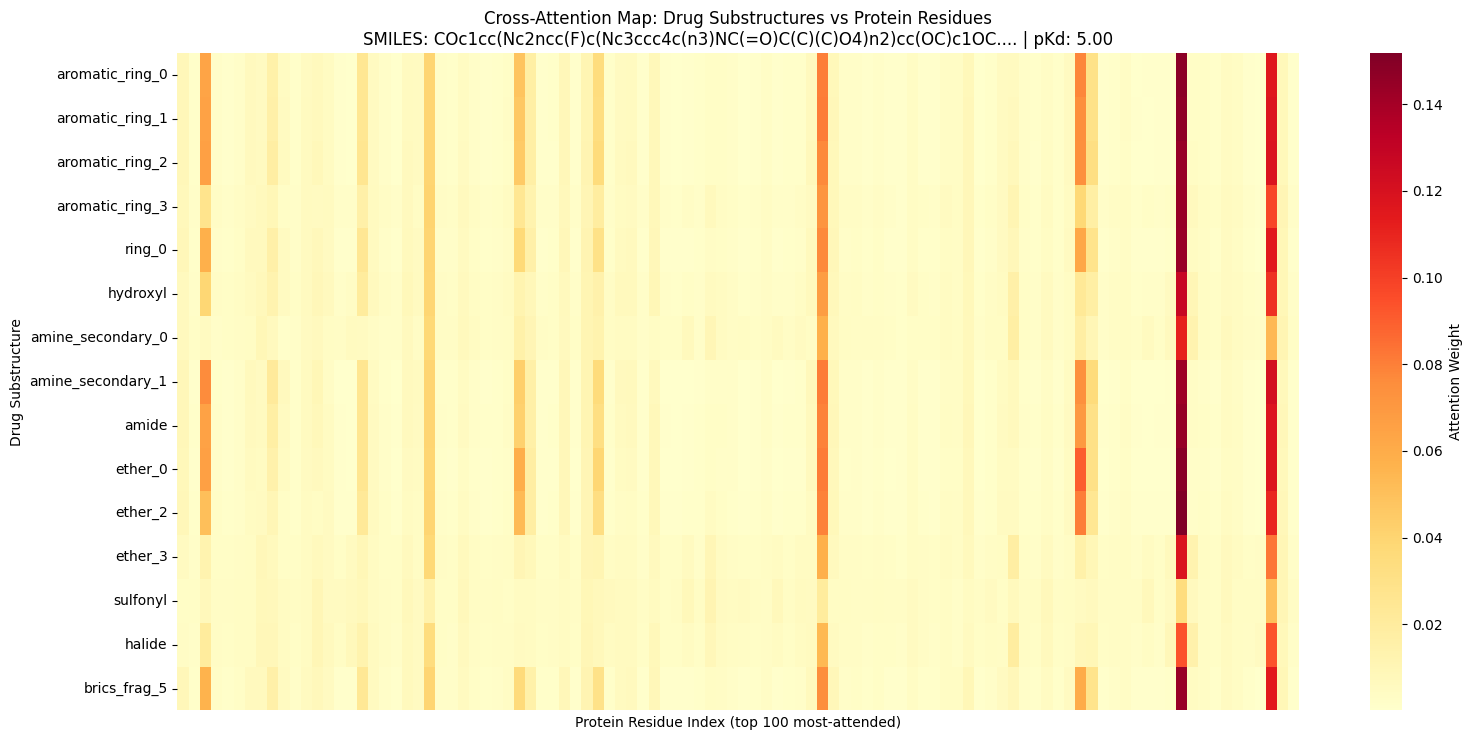


Top 10 predicted binding contacts (substructure → residue):
------------------------------------------------------------
   1. ether_2                   → Residue  265 (C) | weight: 0.1517
   2. ether_0                   → Residue  265 (C) | weight: 0.1493
   3. aromatic_ring_0           → Residue  265 (C) | weight: 0.1477
   4. aromatic_ring_1           → Residue  265 (C) | weight: 0.1467
   5. amide                     → Residue  265 (C) | weight: 0.1452
   6. aromatic_ring_3           → Residue  265 (C) | weight: 0.1444
   7. aromatic_ring_2           → Residue  265 (C) | weight: 0.1442
   8. ring_0                    → Residue  265 (C) | weight: 0.1440
   9. brics_frag_5              → Residue  265 (C) | weight: 0.1435
  10. amine_secondary_1         → Residue  265 (C) | weight: 0.1427


In [16]:
# ============================================================
# Cell 13: Attention Map Visualization (Interpretability)
# ============================================================

@torch.no_grad()
def get_attention_map(model, batch, device, sample_idx=0):
    """Extract attention map for a single sample."""
    model.eval()
    
    drug_emb = batch['drug_emb'].to(device)
    drug_mask = batch['drug_mask'].to(device)
    protein_emb = batch['protein_emb'].to(device)
    protein_mask = batch['protein_mask'].to(device)
    sub_mask = batch['sub_mask'].to(device)
    sub_padding_mask = batch['sub_padding_mask'].to(device)
    
    _, attn_map = model(
        drug_emb, drug_mask, protein_emb, protein_mask,
        sub_mask, sub_padding_mask
    )
    
    # Get the attention map for the specified sample
    attn = attn_map[sample_idx].cpu().numpy()  # (N_sub, L_p)
    
    # Get valid dimensions
    n_sub = batch['n_sub'][sample_idx]
    protein_len = int(batch['protein_mask'][sample_idx].sum().item())
    
    # Trim to valid region
    attn = attn[:n_sub, :protein_len]
    
    return attn


# Get a test batch
test_batch = next(iter(test_loader))

# Pick the first sample
sample_idx = 0
attn_map = get_attention_map(model_cached, test_batch, device, sample_idx)
sub_names = test_batch['sub_names'][sample_idx]
smiles = test_batch['smiles'][sample_idx]
protein = test_batch['protein'][sample_idx]
true_pKd = test_batch['pKd'][sample_idx].item()

print(f"Drug: {smiles}")
print(f"Protein (first 50 residues): {protein[:50]}...")
print(f"True pKd: {true_pKd:.3f}")
print(f"Attention map shape: {attn_map.shape} (substructures × residues)")

# --- Plot attention heatmap ---
fig, ax = plt.subplots(figsize=(16, max(4, len(sub_names) * 0.5)))

# Subsample protein residues for visualization if too long
max_residues_to_show = 100
protein_len = attn_map.shape[1]

if protein_len > max_residues_to_show:
    # Show top-attended residue regions
    residue_importance = attn_map.sum(axis=0)
    top_residues = np.argsort(residue_importance)[-max_residues_to_show:]
    top_residues = np.sort(top_residues)
    attn_display = attn_map[:, top_residues]
    x_labels = [str(r) for r in top_residues]
    xlabel = f"Protein Residue Index (top {max_residues_to_show} most-attended)"
else:
    attn_display = attn_map
    x_labels = [f"{i}" for i in range(protein_len)]
    xlabel = "Protein Residue Index"

sns.heatmap(
    attn_display,
    xticklabels=x_labels if protein_len <= 50 else False,
    yticklabels=sub_names,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Attention Weight'}
)

ax.set_xlabel(xlabel)
ax.set_ylabel('Drug Substructure')
ax.set_title(f'Cross-Attention Map: Drug Substructures vs Protein Residues\n'
             f'SMILES: {smiles[:60]}{"..." if len(smiles) > 60 else ""} | pKd: {true_pKd:.2f}')

plt.tight_layout()
plt.show()

# --- Show top binding contacts ---
print("\nTop 10 predicted binding contacts (substructure → residue):")
print("-" * 60)
flat_indices = np.argsort(attn_map.ravel())[::-1][:10]
for rank, flat_idx in enumerate(flat_indices, 1):
    sub_idx = flat_idx // attn_map.shape[1]
    res_idx = flat_idx % attn_map.shape[1]
    weight = attn_map[sub_idx, res_idx]
    sub_name = sub_names[sub_idx] if sub_idx < len(sub_names) else f"sub_{sub_idx}"
    residue = protein[res_idx] if res_idx < len(protein) else "?"
    print(f"  {rank:2d}. {sub_name:<25} → Residue {res_idx:4d} ({residue}) | weight: {weight:.4f}")

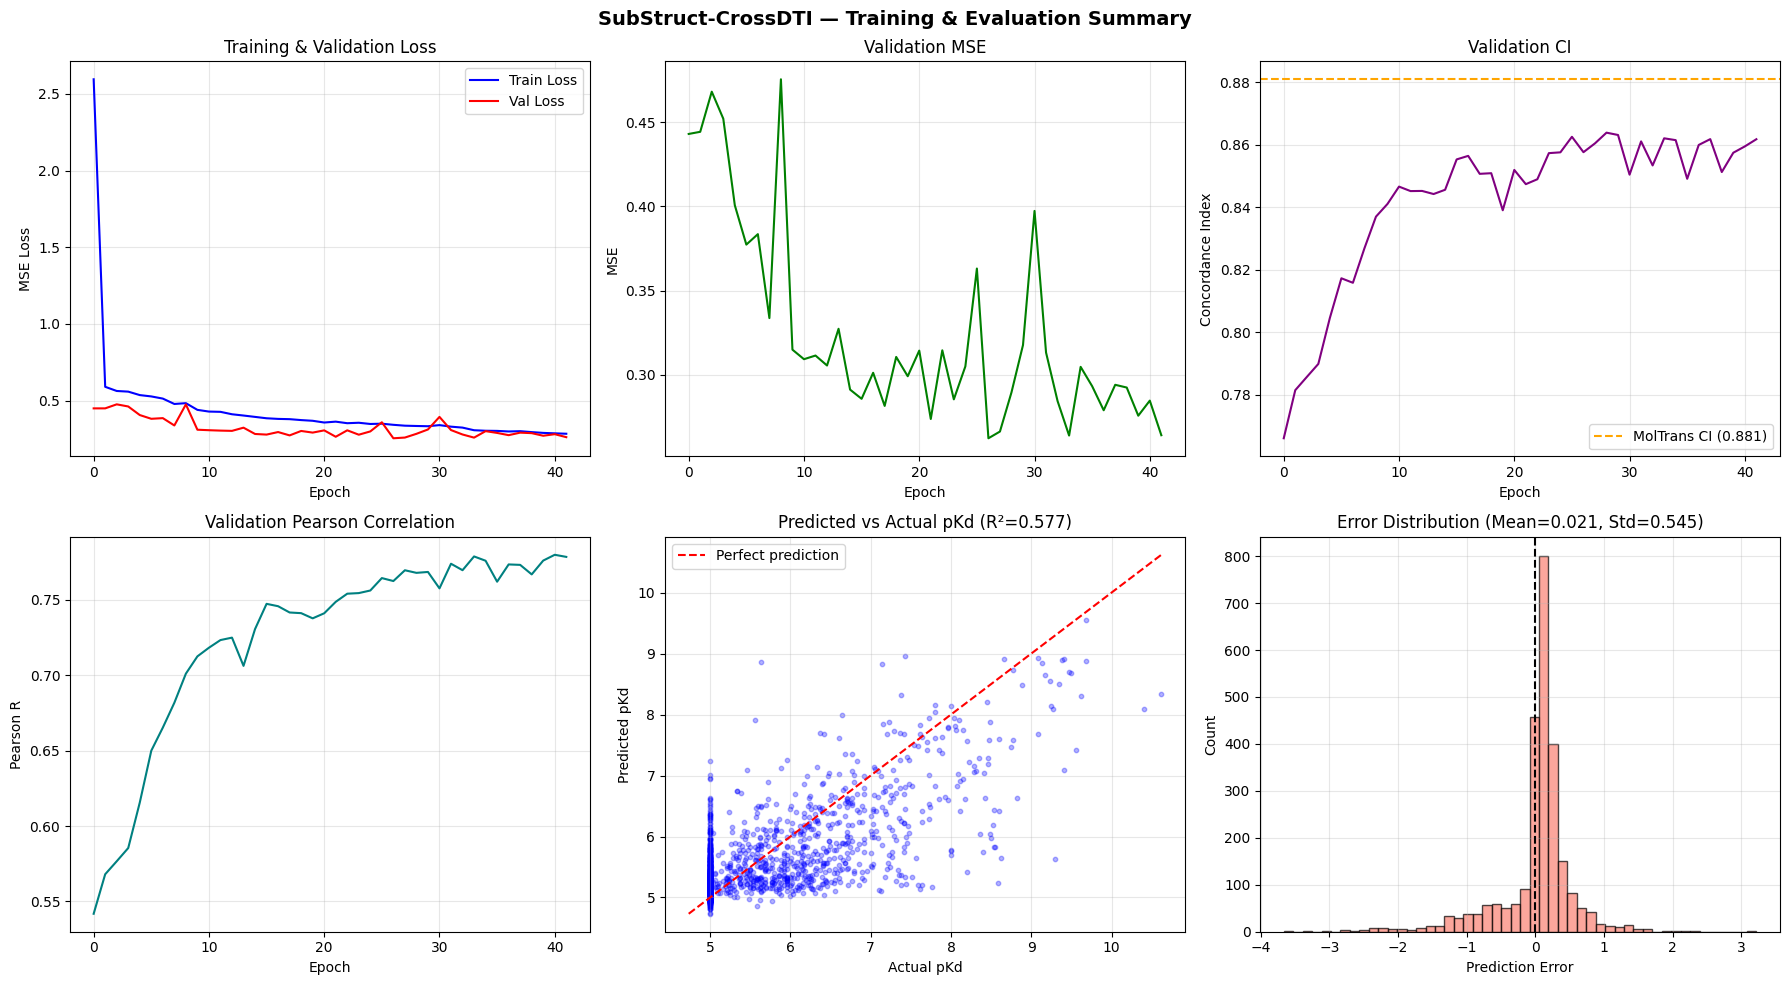

Figures saved to /kaggle/working//training_results.png

FINAL SUMMARY — SubStruct-CrossDTI
Architecture: Frozen seyonec/ChemBERTa-zinc250k-v1 + Frozen esm2_t6_8M_UR50D + Hierarchical Cross-Attention
Dataset: DAVIS (20617 train / 2577 val / 2578 test)
Trainable params: 3,859,713
Best epoch: 27

Test Results:
         MSE: 0.2979
        RMSE: 0.5458
   PEARSON_R: 0.7601
          R2: 0.5766
          CI: 0.8476


In [17]:
# ============================================================
# Cell 14: Training Curves & Additional Visualizations
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0, 0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training & Validation Loss'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['val_mse'], color='green')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('MSE')
axes[0, 1].set_title('Validation MSE'); axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(history['val_ci'], color='purple')
axes[0, 2].set_xlabel('Epoch'); axes[0, 2].set_ylabel('Concordance Index')
axes[0, 2].set_title('Validation CI')
axes[0, 2].axhline(y=0.881, color='orange', linestyle='--', label='MolTrans CI (0.881)')
axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(history['val_pearson'], color='teal')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Pearson R')
axes[1, 0].set_title('Validation Pearson Correlation'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(test_targets, test_preds, alpha=0.3, s=10, color='blue')
min_val = min(min(test_targets), min(test_preds))
max_val = max(max(test_targets), max(test_preds))
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[1, 1].set_xlabel('Actual pKd'); axes[1, 1].set_ylabel('Predicted pKd')
axes[1, 1].set_title(f'Predicted vs Actual pKd (R²={test_metrics["r2"]:.3f})')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

errors = np.array(test_preds) - np.array(test_targets)
axes[1, 2].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='salmon')
axes[1, 2].axvline(x=0, color='black', linestyle='--')
axes[1, 2].set_xlabel('Prediction Error'); axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title(f'Error Distribution (Mean={errors.mean():.3f}, Std={errors.std():.3f})')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('SubStruct-CrossDTI — Training & Evaluation Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"Figures saved to {RESULTS_PLOT_PATH}")

print("\n" + "=" * 60)
print("FINAL SUMMARY — SubStruct-CrossDTI")
print("=" * 60)
print(f"Architecture: Frozen {CHEMBERTA_MODEL} + Frozen {ESM2_MODEL} + Hierarchical Cross-Attention")
print(f"Dataset: {DATASET_NAME} ({len(train_df)} train / {len(val_df)} val / {len(test_df)} test)")
print(f"Trainable params: {sum(p.numel() for p in model_cached.parameters() if p.requires_grad):,}")
print(f"Best epoch: {history['val_loss'].index(min(history['val_loss'])) + 1}")
print(f"\nTest Results:")
for k in ['mse', 'rmse', 'pearson_r', 'r2', 'ci']:
    print(f"  {k.upper():>10}: {test_metrics[k]:.4f}")
print("=" * 60)